# Product Satisfaction from Review Text

This is an **independent experimental extension**. It does not improve the
selfie colour matcher directly. The goal is to predict whether a review is
positive from its text using a TF-IDF and logistic-regression baseline.

The split is grouped by product so that reviews for the same product do
not appear in both training and test sets.


## 1. Setup


In [5]:
from pathlib import Path
import os
import subprocess
import sys

REPOSITORY_URL = "https://github.com/amafteeva/Predictive-beauty-analysis-using-computer-vision-and-machine-learning-.git"


def find_project_root(start: Path) -> Path | None:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return None


project_root = find_project_root(Path.cwd())

if project_root is None and "google.colab" in sys.modules:
    if "YOUR_USERNAME" in REPOSITORY_URL:
        raise ValueError(
            "Replace YOUR_USERNAME in REPOSITORY_URL after publishing the project to GitHub."
        )
    project_root = Path("/content/foundation-shade-recommender")
    if not project_root.exists():
        subprocess.run(["git", "clone", REPOSITORY_URL, str(project_root)], check=True)

if project_root is None:
    raise FileNotFoundError("Run this notebook from inside the project folder.")

os.chdir(project_root)

# Connect the local `foundation_matcher` package (src/ layout) so the
# imports below resolve even if the editable install has not been run.
src_path = project_root / "src"
if src_path.is_dir() and str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

# Install the package and its dependencies. Non-fatal: if a dependency
# wheel is unavailable the local package is still importable via src_path.
result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "-e", "."],
    check=False,
)
if result.returncode != 0:
    print("Warning: `pip install -e .` failed; using src/ on sys.path instead.")

import importlib.util

if importlib.util.find_spec("foundation_matcher") is None:
    raise ModuleNotFoundError(
        f"foundation_matcher not found. Expected package at {src_path}."
    )

print("Project root:", project_root)
print("foundation_matcher connected from:", src_path)


Project root: /Users/mafteevaalina/Downloads/capstone/Predictive-beauty-analysis-using-computer-vision-and-machine-learning-
foundation_matcher connected from: /Users/mafteevaalina/Downloads/capstone/Predictive-beauty-analysis-using-computer-vision-and-machine-learning-/src


In [6]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.metrics import ConfusionMatrixDisplay

from foundation_matcher.config import LUXXIFY_REVIEW_URL
from foundation_matcher.review_model import (
    build_review_classifier,
    evaluate_review_classifier,
    grouped_train_test_split,
    prepare_review_data,
)


## 2. Load and prepare reviews

Ratings of 4 or 5 are labelled positive. Because the dataset is strongly
imbalanced, later evaluation includes balanced accuracy, class-specific
precision/recall/F1, ROC AUC, and average precision—not accuracy alone.


In [7]:
makeup_reviews = pd.read_csv(LUXXIFY_REVIEW_URL, low_memory=False)

print("Raw review shape:", makeup_reviews.shape)
print("Available columns:", makeup_reviews.columns.tolist())

# This export stores the review body in `comments`, the star rating in
# `rating`, and the product identifier in `product_link_id`.
review_ml = prepare_review_data(
    makeup_reviews,
    text_column="comments",
    rating_column="rating",
    group_column="product_link_id",
    positive_threshold=4,
)

print("Prepared examples:", len(review_ml))
display(
    review_ml["positive_review"]
    .value_counts()
    .rename_axis("class")
    .to_frame("count")
    .assign(proportion=lambda table: table["count"] / table["count"].sum())
)


Raw review shape: (314029, 27)
Available columns: ['unique_review_id', 'product_link_id', 'review_id', 'type', 'id', 'ugc_id', 'legacy_id', 'internal_review_id', 'headline', 'nickname', 'created_date', 'updated_date', 'rating', 'helpful_votes', 'not_helpful_votes', 'uri', 'comments', 'locale', 'location', 'bottom_line', 'product_page_id', 'upc', 'gtin', 'is_staff_reviewer', 'is_verified_buyer', 'is_verified_reviewer', 'helpful_score']
Prepared examples: 28185


,count,proportion
class,,
1,20772,0.736988
0,7413,0.263012


### Optional Colab-sized sample

The full dataset can be used by setting `MAX_ROWS = None`. The default
keeps the baseline practical on a standard Colab runtime while retaining
both classes. This is a development sample, not a final benchmark.


In [8]:
MAX_ROWS = 120_000

if MAX_ROWS is not None and len(review_ml) > MAX_ROWS:
    fraction = MAX_ROWS / len(review_ml)
    review_ml = (
        review_ml.groupby("positive_review", group_keys=False)
        .sample(frac=fraction, random_state=42)
        .sample(frac=1, random_state=42)
        .reset_index(drop=True)
    )

print("Examples used:", len(review_ml))


Examples used: 28185


## 3. Make a product-grouped train/test split


In [9]:
(
    X_train,
    X_test,
    y_train,
    y_test,
    train_groups,
    test_groups,
) = grouped_train_test_split(review_ml)

product_overlap = set(train_groups).intersection(test_groups)
assert not product_overlap, "Product leakage detected."

print(f"Training reviews: {len(X_train):,}")
print(f"Testing reviews: {len(X_test):,}")
print("Products appearing in both sets:", len(product_overlap))
print("Training positive rate:", f"{y_train.mean():.1%}")
print("Testing positive rate:", f"{y_test.mean():.1%}")


Training reviews: 22,544
Testing reviews: 5,641
Products appearing in both sets: 0
Training positive rate: 73.7%
Testing positive rate: 73.7%


## 4. Train the baseline


In [10]:
review_classifier = build_review_classifier(
    max_features=40_000,
    minimum_document_frequency=5,
)

review_classifier.fit(X_train, y_train)
print("Training complete.")


Training complete.


/opt/anaconda3/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


## 5. Evaluate with imbalance-aware metrics


Always-positive accuracy: 0.737


,score
accuracy,0.880
balanced_accuracy,0.872
precision,0.945
recall,0.889
f1,0.916
roc_auc,0.938
average_precision,0.973


,precision,recall,f1-score,support
negative,0.734,0.855,0.790,1485.00
positive,0.945,0.889,0.916,4156.00
accuracy,0.880,0.880,0.880,0.88
macro avg,0.839,0.872,0.853,5641.00
weighted avg,0.889,0.880,0.883,5641.00


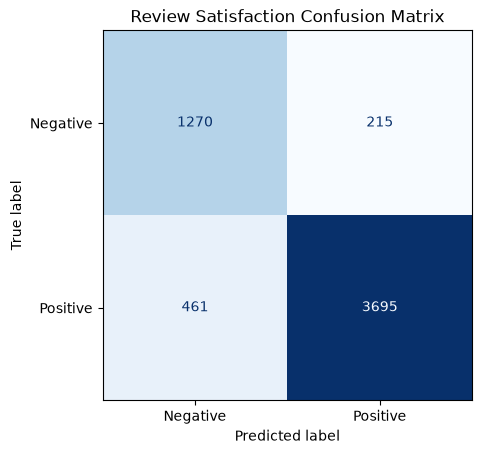

In [11]:
metrics, classification_table, confusion = evaluate_review_classifier(
    review_classifier,
    X_test,
    y_test,
)

always_positive_accuracy = y_test.mean()
print("Always-positive accuracy:", f"{always_positive_accuracy:.3f}")
display(metrics.to_frame().round(3))
display(classification_table.round(3))

ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=["Negative", "Positive"],
).plot(cmap="Blues", colorbar=False)
plt.title("Review Satisfaction Confusion Matrix")
plt.grid(False)
plt.show()


## 6. Inspect influential words and phrases


In [12]:
feature_names = review_classifier.named_steps["tfidf"].get_feature_names_out()
coefficients = review_classifier.named_steps["classifier"].coef_[0]

coefficient_table = pd.DataFrame(
    {"term": feature_names, "coefficient": coefficients}
)

print("Terms most associated with negative reviews")
display(coefficient_table.nsmallest(15, "coefficient"))

print("Terms most associated with positive reviews")
display(coefficient_table.nlargest(15, "coefficient"))


Terms most associated with negative reviews


,term,coefficient
16346,unfortunately,-5.676504
4073,disappointed,-5.260329
16996,wanted love,-4.921624
786,bad,-4.800554
13197,returning,-4.618908
13190,return,-4.341193
13194,returned,-4.233616
15504,terrible,-4.233191
771,awful,-4.187559
1754,broke,-4.182250


Terms most associated with positive reviews


,term,coefficient
9249,love,9.321557
11210,perfect,7.388450
404,amazing,6.252184
6720,great,5.927497
1013,best,5.617953
10355,natural,4.618810
4591,easy,4.340867
900,beautiful,4.206608
6214,gives,3.992294
7111,helps,3.908312


## 7. Interpretation and next steps

Compare the trained model with the always-positive baseline. High raw
accuracy is not impressive when most reviews are positive. Balanced
accuracy and negative-class recall reveal whether the classifier learns
useful minority-class signals.

Ratings are used to create the label, so this experiment predicts
rating-derived sentiment rather than long-term product satisfaction.
Stronger work could add calibration, repeated grouped cross-validation,
error analysis, and product metadata while preserving product-level
separation between training and evaluation.
